# Numerical Simulation Laboratory - Exercise 12

## INTRODUCTION

### Deep neural networks and image data

The goal of this exercise is the classification of the MNIST handwritten digits. Each sample is a grayscale image of size $28 \times 28$, so the input contains $784$ pixel values and the output class is one of the ten digits from $0$ to $9$.

A fully connected deep neural network treats the image as a one-dimensional vector. This is sufficient to build a classifier, but it does not explicitly exploit the fact that neighbouring pixels are spatially related. In image-recognition tasks this spatial structure is important: local features such as edges, loops, corners and strokes are meaningful, and similar features may appear in different positions of the image.

### Locality, translational invariance and convolutional neural networks

Convolutional Neural Networks are designed to exploit two properties that are very natural in image data:

- **locality**, because the relevant elementary features are usually contained in small spatial regions;
- **translational invariance**, because a feature should remain useful even if it appears in a slightly different position.

A convolutional layer applies a set of filters to local patches of the previous layer. The same filter is translated over the image, so the same group of trainable weights is reused at many spatial positions. This weight sharing strongly reduces the number of parameters with respect to a fully connected layer and makes the model more suitable for image classification.

For an input width $W$, a filter size $F$, padding $P$ and stride $S$, the one-dimensional output size is

$$
1+\frac{W-F+2P}{S}.
$$

The same reasoning applies independently to the two spatial directions in a two-dimensional image. The depth of a layer corresponds to the number of channels: one channel for grayscale images, three channels for RGB images, and several learned feature maps inside a CNN.

### Pooling, flattening and final classification

Pooling layers reduce the spatial size of the representation while keeping the channel structure. In max pooling, each small region is replaced by its maximum activation. This operation acts as a local coarse graining: it keeps the strongest local response and makes the representation less sensitive to small shifts.

After the convolutional and pooling layers, the multidimensional feature maps are flattened into a vector. The final dense layers then perform the classification, and the last softmax layer returns a normalized probability distribution over the ten possible digits.

<p align="center">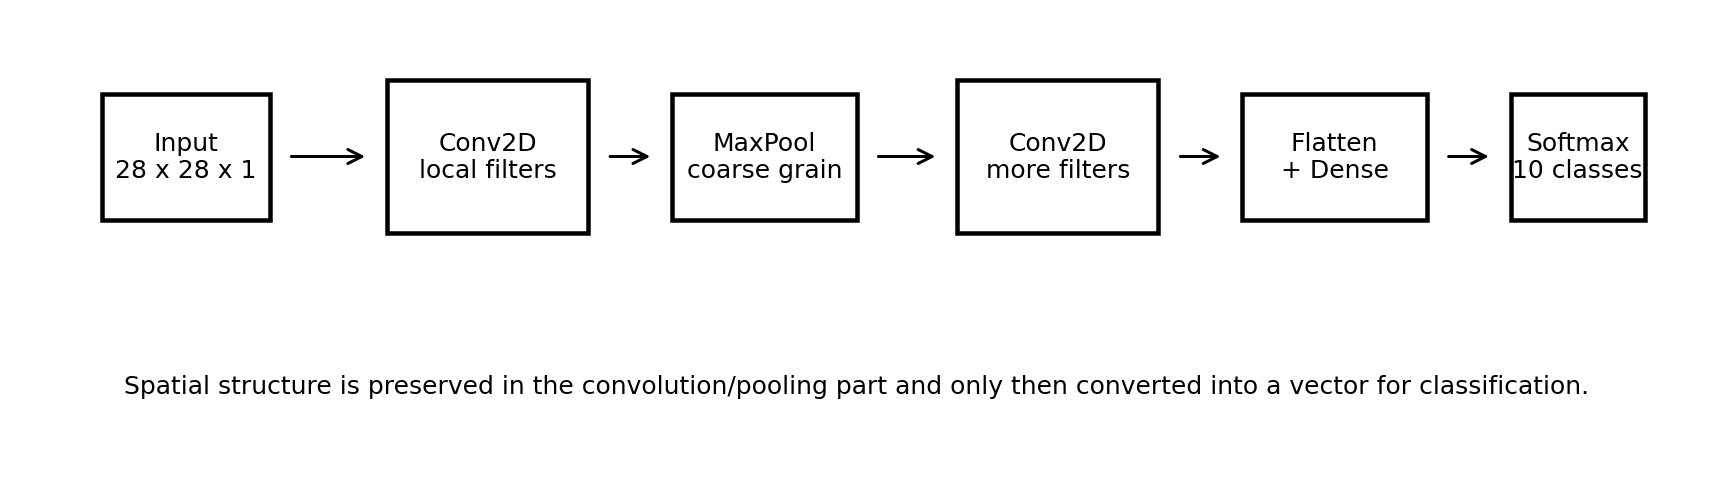</p>

### MNIST dataset loading and preprocessing

In [20]:
import random
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad

seed = 123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)

In [21]:
img_rows, img_cols = 28, 28
num_classes = 10

(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

# DNN input: each image is flattened into a vector of 784 pixels.
X_train_DNN = X_train_raw.reshape(X_train_raw.shape[0], img_rows * img_cols).astype("float32") / 255.0
X_test_DNN = X_test_raw.reshape(X_test_raw.shape[0], img_rows * img_cols).astype("float32") / 255.0

# CNN input: each image keeps its two-dimensional structure and has one grayscale channel.
if keras.backend.image_data_format() == "channels_first":
    X_train_CNN = X_train_raw.reshape(X_train_raw.shape[0], 1, img_rows, img_cols).astype("float32") / 255.0
    X_test_CNN = X_test_raw.reshape(X_test_raw.shape[0], 1, img_rows, img_cols).astype("float32") / 255.0
    input_shape = (1, img_rows, img_cols)
else:
    X_train_CNN = X_train_raw.reshape(X_train_raw.shape[0], img_rows, img_cols, 1).astype("float32") / 255.0
    X_test_CNN = X_test_raw.reshape(X_test_raw.shape[0], img_rows, img_cols, 1).astype("float32") / 255.0
    input_shape = (img_rows, img_cols, 1)

Y_train = to_categorical(y_train, num_classes)
Y_test = to_categorical(y_test, num_classes)

print("Raw training set:", X_train_raw.shape)
print("DNN training input:", X_train_DNN.shape)
print("CNN training input:", X_train_CNN.shape)
print("One-hot labels:", Y_train.shape)
print("CNN input shape:", input_shape)

Raw training set: (60000, 28, 28)
DNN training input: (60000, 784)
CNN training input: (60000, 28, 28, 1)
One-hot labels: (60000, 10)
CNN input shape: (28, 28, 1)


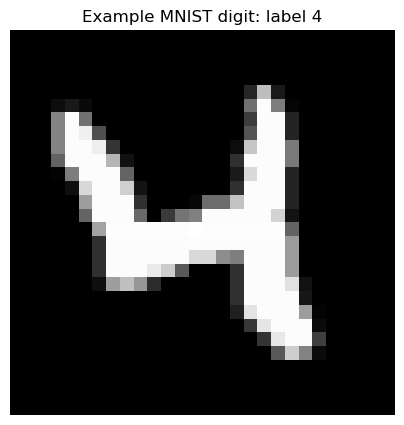

One-hot encoded label: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [22]:
sample_index = 20

plt.figure(figsize=(5, 5))
plt.imshow(X_train_raw[sample_index], cmap="gray")
plt.title(f"Example MNIST digit: label {y_train[sample_index]}")
plt.axis("off")
plt.show()

print("One-hot encoded label:", Y_train[sample_index])

## EXERCISE 12.1

### Assignment prompt

Change at will and train your DNN by increasing the number of epochs to an adeuqate value</span>. Try to use at least two other optimizers, different from SGD: watch to accuracy and loss for training and validation data and comment on the performances.

### Method

A fully connected DNN is trained on the flattened MNIST images. The same architecture is used for all optimizers, so the comparison focuses on the optimization algorithm rather than on the model capacity. Four optimizers are considered:

- SGD, used as a baseline;
- Adam;
- RMSprop;
- Adagrad.

The training is performed for a fixed number of epochs. Early stopping is not used in this comparison, so all optimizers are trained for the same number of epochs and their learning curves can be compared directly.

### DNN architecture

In [23]:
def create_DNN():
    model = Sequential(name="mnist_dnn")
    model.add(Input(shape=(img_rows * img_cols,)))
    model.add(Dense(200, activation="relu"))
    model.add(Dense(100, activation="relu"))
    model.add(Dense(500, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation="softmax"))
    return model

model_DNN_example = create_DNN()
# model_DNN_example.summary()

### Training with different optimizers

In the following cell, the optimizers used to train the DNN are defined. Each optimizer is written inside a `lambda` function so that a new independent optimizer object is created every time a new model is compiled.

The parameter `learning_rate` controls the overall size of the update step. In `SGD`, it directly fixes the step taken in the direction opposite to the gradient. `Adam` combines momentum-like information with an adaptive normalization of the gradients: `beta_1` controls the exponential average of the gradients, while `beta_2` controls the exponential average of the squared gradients. `RMSprop` also uses the squared gradients to adapt the updates, and the parameter `rho` controls the memory of this running average. Finally, `Adagrad` accumulates the squared gradients over the whole training history, so parameters that have already received large gradients are updated more cautiously.

In [24]:
batch_size = 64
epochs = 30

optimizer_list = {
    "SGD": lambda: SGD(learning_rate=0.01),
    "Adam": lambda: Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999),
    "RMSprop": lambda: RMSprop(learning_rate=0.0001, rho=0.9),
    "Adagrad": lambda: Adagrad(learning_rate=0.01),
}

histories_DNN = {}
models_DNN = {}

for opt_name, make_optimizer in optimizer_list.items():
    print(f"\nTraining with optimizer: {opt_name}\n")

    model_DNN = create_DNN()
    model_DNN.compile(
        loss="categorical_crossentropy",
        optimizer=make_optimizer(),
        metrics=["accuracy"],
    )

    history_DNN = model_DNN.fit(
        X_train_DNN,
        Y_train,
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        verbose=1,
        validation_data=(X_test_DNN, Y_test),
    )

    histories_DNN[opt_name] = history_DNN
    models_DNN[opt_name] = model_DNN


Training with optimizer: SGD

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6557 - loss: 1.1429 - val_accuracy: 0.8896 - val_loss: 0.4188
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8800 - loss: 0.4098 - val_accuracy: 0.9177 - val_loss: 0.2959
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9075 - loss: 0.3191 - val_accuracy: 0.9293 - val_loss: 0.2478
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9201 - loss: 0.2723 - val_accuracy: 0.9362 - val_loss: 0.2185
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9293 - loss: 0.2421 - val_accuracy: 0.9424 - val_loss: 0.1950
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9376 - loss: 0.2167 - val_accuracy: 0.9476 - val_loss: 0.1765
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9429 - loss: 0.1963 - val_accuracy: 0.9506 - val_loss: 0.1638
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9470 - 

### Optimizer comparison

In [25]:
print("Performance of the different optimizers\n")

for opt_name, trained_model in models_DNN.items():
    train_loss, train_acc = trained_model.evaluate(X_train_DNN, Y_train, verbose=0)
    val_loss, val_acc = trained_model.evaluate(X_test_DNN, Y_test, verbose=0)

    print(f"Optimizer: {opt_name}")
    print(f"Train loss:      {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print(f"Train accuracy:  {train_acc:.4f}")
    print(f"Validation acc:  {val_acc:.4f}")
    print("-" * 40)

Performance of the different optimizers

Optimizer: SGD
Train loss:      0.0426
Validation loss: 0.0736
Train accuracy:  0.9883
Validation acc:  0.9758
----------------------------------------
Optimizer: Adam
Train loss:      0.0039
Validation loss: 0.0890
Train accuracy:  0.9992
Validation acc:  0.9783
----------------------------------------
Optimizer: RMSprop
Train loss:      0.0063
Validation loss: 0.0962
Train accuracy:  0.9985
Validation acc:  0.9783
----------------------------------------
Optimizer: Adagrad
Train loss:      0.0147
Validation loss: 0.0715
Train accuracy:  0.9972
Validation acc:  0.9789
----------------------------------------


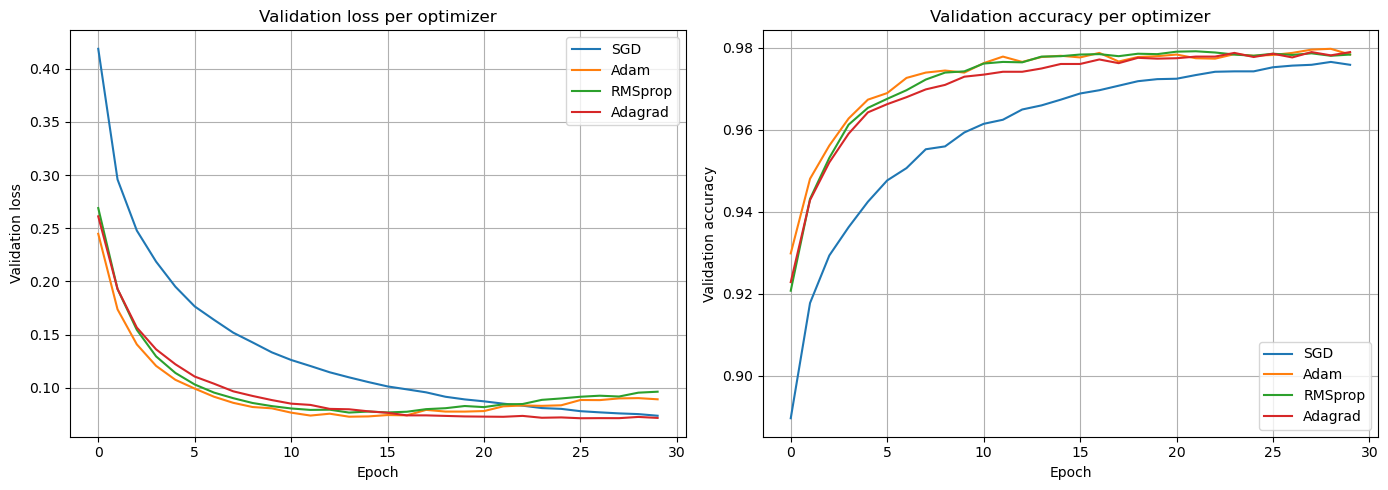

In [26]:
def get_accuracy_keys(history):
    keys = history.history.keys()
    if "accuracy" in keys:
        return "accuracy", "val_accuracy"
    return "acc", "val_acc"


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for opt_name, history_DNN in histories_DNN.items():

    acc_key, val_acc_key = get_accuracy_keys(history_DNN)

    #Commentate per lasciare il plot più leggibile
    
    # axes[0].plot(
    #     history_DNN.history["loss"],
    #     linestyle="--",
    #     label=f"{opt_name} train"
    # )

    axes[0].plot(
        history_DNN.history["val_loss"],
        linestyle="-",
        label=opt_name
    )

    # axes[1].plot(
    #     history_DNN.history[acc_key],
    #     linestyle="--",
    #     label=f"{opt_name} train"
    # )

    axes[1].plot(
        history_DNN.history[val_acc_key],
        linestyle="-",
        label=opt_name
    )


axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation loss")
axes[0].set_title("Validation loss per optimizer")
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Validation accuracy per optimizer")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Comment

The comparison shows that all optimizers are able to train the fully connected network successfully on MNIST, but their convergence speed is different. The curves refer to the validation/test set.

SGD has the slowest convergence. Its validation loss decreases smoothly and its validation accuracy increases regularly, but the improvement is more gradual. This behaviour is expected because standard stochastic gradient descent uses a fixed learning-rate scale and does not adapt the update size separately for different parameters.

Adam, RMSprop and Adagrad converge faster. Their validation loss drops more rapidly during the first epochs and their validation accuracy reaches high values earlier. This is consistent with the fact that these optimizers are more sophisticated adaptive methods: they use information from past gradients, or from accumulated squared gradients, to tune the effective update size during training.

The best validation accuracy reached in this comparison is about **$0.98$**. At the end of training, the differences between the optimizers become smaller, since all curves approach a similar accuracy range. However, the adaptive optimizers reach this regime earlier than SGD.

A mild sign of overfitting can be observed for RMSprop and Adam: after the validation loss reaches its minimum, it stops decreasing and slightly increases. This effect is not strong, because the validation accuracy remains stable and high.

Therefore, the relevant conclusion is that the optimizer mainly affects the speed and regularity of convergence, not only the final accuracy.

### Example predictions with the selected DNN

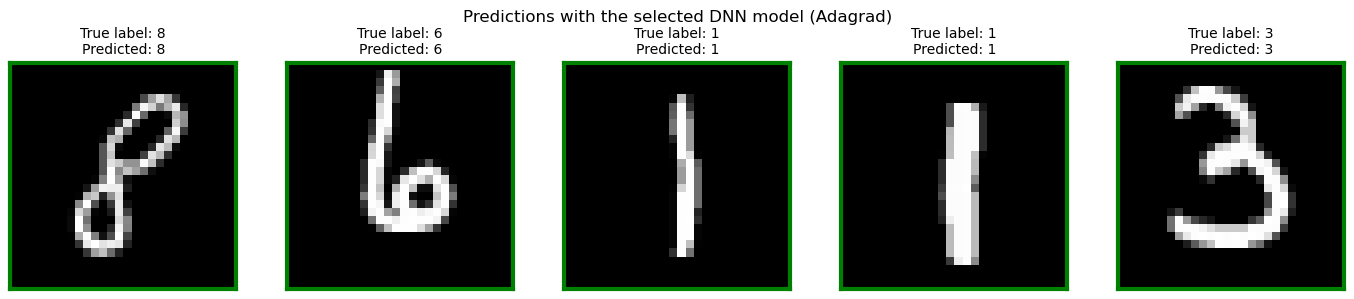

In [27]:
_, val_acc_key = get_accuracy_keys(next(iter(histories_DNN.values())))

best_optimizer_name = max(
    histories_DNN,
    key=lambda opt_name: histories_DNN[opt_name].history[val_acc_key][-1]
)

best_DNN_model = models_DNN[best_optimizer_name]

n_examples = 5
rng = np.random.default_rng(seed)
indices = rng.choice(len(X_test_DNN), size=n_examples, replace=False)

predictions = best_DNN_model.predict(X_test_DNN[indices], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

if len(Y_test.shape) > 1:
    true_labels = np.argmax(Y_test[indices], axis=1)
else:
    true_labels = Y_test[indices]

fig, axes = plt.subplots(1, n_examples, figsize=(14, 3))

for ax, idx, true_label, predicted_label in zip(
    axes, indices, true_labels, predicted_labels
):
    image = X_test_DNN[idx].reshape(img_rows, img_cols)

    ax.imshow(image, cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])

    is_correct = predicted_label == true_label
    border_color = "green" if is_correct else "red"

    ax.set_title(
        f"True label: {true_label}\nPredicted: {predicted_label}",
        fontsize=10,
    )

    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

plt.suptitle(f"Predictions with the selected DNN model ({best_optimizer_name})")
plt.tight_layout()
plt.show()

## EXERCISE 12.2

### Assignment prompt

Change the architecture of your DNN using convolutional layers. Use `Conv2D`, `MaxPooling2D`, `Dropout`, but also do not forget `Flatten`, a standard `Dense` layer and `soft-max` in the end.

### Method

The CNN receives the images in their natural $28 \times 28 \times 1$ shape, so the spatial structure of the digits is preserved. The architecture is built from two convolutional blocks followed by a dense classification head.

The first convolutional layer applies $32$ filters with a $3 \times 3$ kernel, ReLU activation and `same` padding. Starting from an input image of shape $28 \times 28 \times 1$, it produces $32$ feature maps of size $28 \times 28$. The following $2 \times 2$ max-pooling layer reduces the spatial size by a factor of two, giving feature maps of shape $14 \times 14 \times 32$.

The second convolutional layer applies $64$ filters with a $3 \times 3$ kernel, again with ReLU activation and `same` padding. Since the input to this layer has shape $14 \times 14 \times 32$, the output has shape $14 \times 14 \times 64$. The second $2 \times 2$ max-pooling layer further reduces the spatial resolution to $7 \times 7 \times 64$.

The classification head starts with a `Flatten` layer, which transforms the final three-dimensional feature volume into a one-dimensional vector with $7 \cdot 7 \cdot 64 = 3136$ components. This vector is passed to a dense layer with $128$ neurons and ReLU activation. A dropout layer with rate $0.25$ is then applied before the final classification layer, in order to reduce overfitting. The last dense layer has $10$ neurons and softmax activation, and returns the probabilities associated with the ten digit classes.

Dropout is active during training and inactive during validation and testing. Therefore, the training and validation metrics are not computed under exactly the same network conditions: during training, some units are randomly removed, while during validation the full network is used. In this architecture, dropout is applied only in the dense classification head, so this regularization effect is present but not too strong.

The model is trained for a fixed number of epochs, without early stopping, so that the full evolution of the training and validation curves can be inspected. A moderate learning rate is used in order to make the convergence visible over several epochs.

### CNN architecture

In [28]:
def create_CNN(input_shape, num_classes):
    model = Sequential(name="mnist_cnn")
    model.add(Input(shape=input_shape))

    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.25))
    model.add(Dense(num_classes, activation="softmax"))

    return model

model_CNN_example = create_CNN(input_shape, num_classes)
# model_CNN_example.summary()

### Training

In [29]:
model_CNN = create_CNN(input_shape, num_classes)

model_CNN.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.0002),
    metrics=["accuracy"],
)

history_CNN = model_CNN.fit(
    X_train_CNN,
    Y_train,
    batch_size=128,
    epochs=20,
    validation_data=(X_test_CNN, Y_test),
    shuffle=True,
    verbose=1,
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8512 - loss: 0.5152 - val_accuracy: 0.9556 - val_loss: 0.1476
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9567 - loss: 0.1463 - val_accuracy: 0.9751 - val_loss: 0.0773
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9706 - loss: 0.0966 - val_accuracy: 0.9824 - val_loss: 0.0542
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9769 - loss: 0.0748 - val_accuracy: 0.9851 - val_loss: 0.0440
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9811 - loss: 0.0619 - val_accuracy: 0.9868 - val_loss: 0.0379
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9835 - loss: 0.0538 - val_accuracy: 0.9880 - val_loss: 0.0343
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9859 - loss: 0.0463 - val_accuracy: 0.9887 - val_loss: 0.0322
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9878 - loss: 0.0414 - 

### Results

In [30]:
score_CNN = model_CNN.evaluate(X_test_CNN, Y_test, verbose=0)

print("Validation loss:", score_CNN[0])
print("Validation accuracy:", score_CNN[1])

Validation loss: 0.03278697654604912
Validation accuracy: 0.989799976348877


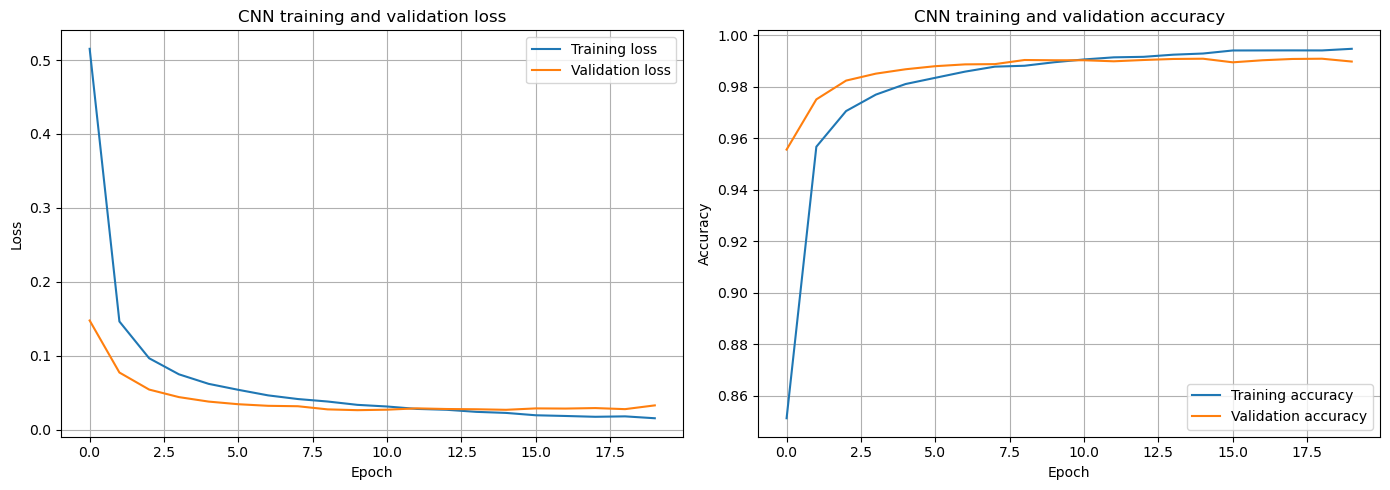

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_CNN.history["loss"], label="Training loss")
axes[0].plot(history_CNN.history["val_loss"], label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("CNN training and validation loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_CNN.history["accuracy"], label="Training accuracy")
axes[1].plot(history_CNN.history["val_accuracy"], label="Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("CNN training and validation accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

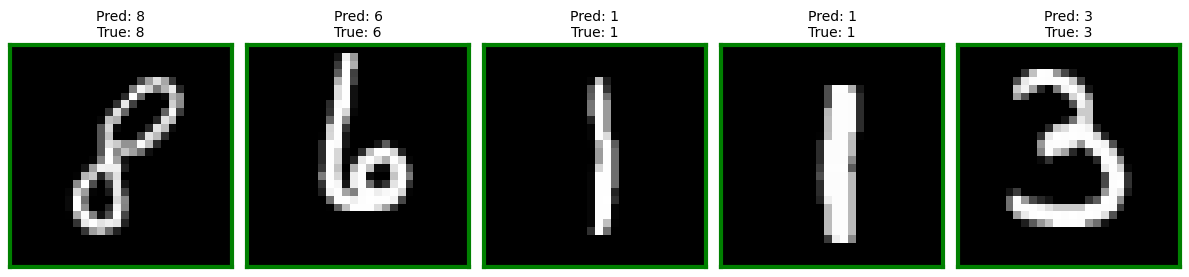

In [32]:
rng = np.random.default_rng(seed)
idx = rng.choice(X_test_CNN.shape[0], 5, replace=False)

images = X_test_CNN[idx]
true_labels = np.argmax(Y_test[idx], axis=1)
predictions = model_CNN.predict(images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i, ax in enumerate(axes):
    if keras.backend.image_data_format() == "channels_first":
        img = images[i, 0, :, :]
    else:
        img = images[i, :, :, 0]

    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}",
        fontsize=10,
    )
    ax.set_xticks([])
    ax.set_yticks([])

    is_correct = predicted_labels[i] == true_labels[i]
    border_color = "green" if is_correct else "red"

    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.show()

### Comment

The CNN reaches a high test accuracy (**$0.99$**), slightly higher than the fully connected DNNs of Exercise 12.1. This improvement is expected because the CNN uses the spatial structure of the images instead of treating all pixels as unrelated input variables.

The validation loss decreases rapidly and remains small. This shows that the convolutional filters learn useful local features for digit recognition. After the first epochs, the training loss continues to decrease slowly, while the validation loss has already reached a low value and only shows small fluctuations. This indicates that most of the useful generalization has already been learned.

The final model is saved in the variable `model_CNN`. The same trained CNN is used in Exercise 12.3 and in the supplementary visualization of filters and activation maps.

## EXERCISE 12.3

### Assignment prompt

### Exercise 12.3

Use the `gimp` application to create 10 pictures of your "handwritten" digits, import them in your jupyter-notebook and try to see if your CNN is able to recognize your handwritten digits.

For example, you can use the following code to import a picture of an handwritten digit
(Note: you should install Python Image Library (PIL/Pillow):

### Method

The ten custom digits are loaded from the folder `MY_DIGITS`. Each image is converted to grayscale, resized to $28 \times 28$ and normalized to the interval $[0,1]$.

The CNN trained in Exercise 12.2 is reused directly. This makes the test on custom digits a genuine application of the already trained classifier. Training or fine-tuning the network on these same custom images would not be conceptually correct: only ten images are available, which is far too little for a meaningful training procedure. Moreover, using these images both to adapt the model and then to evaluate it would introduce data leakage, because the test examples would no longer be independent from the training process.

In [33]:
custom_digits_folder = Path("./MY_DIGITS")

def numeric_sort_key(path):
    stem = Path(path).stem
    return int(stem) if stem.isdigit() else stem

def load_custom_digit(filename):
    img = Image.open(filename).convert("L").resize((img_cols, img_rows))
    data = np.asarray(img).astype("float32") / 255.0

    # MNIST uses a dark background and bright digits. If the exported image has a
    # bright background on average, the intensity is inverted automatically.
    if data.mean() > 0.5:
        data = 1.0 - data

    return data

digit_files = sorted(custom_digits_folder.glob("*.png"), key=numeric_sort_key)

print("Images found:")
for filename in digit_files:
    print(filename)

if len(digit_files) == 0:
    raise ValueError("No PNG images found in the MY_DIGITS folder.")

custom_images_2d = np.array([load_custom_digit(filename) for filename in digit_files])
custom_true_labels = [int(filename.stem) if filename.stem.isdigit() else None for filename in digit_files]

if keras.backend.image_data_format() == "channels_first":
    custom_images = custom_images_2d.reshape(custom_images_2d.shape[0], 1, img_rows, img_cols)
else:
    custom_images = custom_images_2d.reshape(custom_images_2d.shape[0], img_rows, img_cols, 1)

print("Shape before channel reshape:", custom_images_2d.shape)
print("Shape after channel reshape:", custom_images.shape)

Images found:
MY_DIGITS\0.png
MY_DIGITS\1.png
MY_DIGITS\2.png
MY_DIGITS\3.png
MY_DIGITS\4.png
MY_DIGITS\5.png
MY_DIGITS\6.png
MY_DIGITS\7.png
MY_DIGITS\8.png
MY_DIGITS\9.png
Shape before channel reshape: (10, 28, 28)
Shape after channel reshape: (10, 28, 28, 1)


Custom digit predictions
file | expected | predicted | confidence
------------------------------------------
0.png |    0     |     0     | 0.997
1.png |    1     |     1     | 0.628
2.png |    2     |     2     | 0.900
3.png |    3     |     3     | 0.999
4.png |    4     |     4     | 0.595
5.png |    5     |     5     | 1.000
6.png |    6     |     6     | 0.991
7.png |    7     |     7     | 0.999
8.png |    8     |     8     | 0.958
9.png |    9     |     7     | 0.541


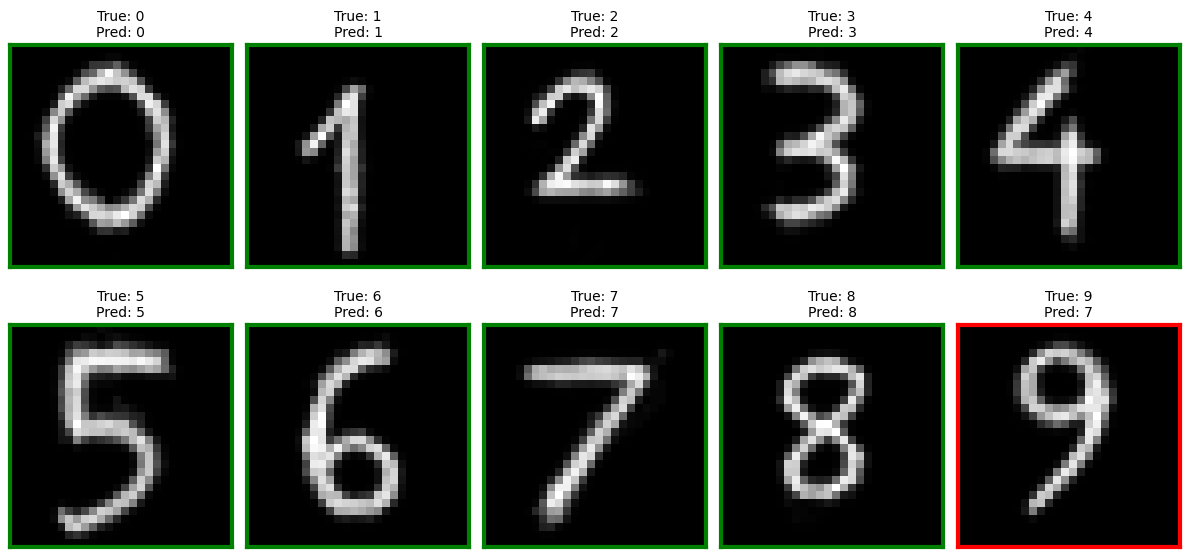

In [34]:
custom_predictions = model_CNN.predict(custom_images, verbose=0)
custom_predicted_labels = np.argmax(custom_predictions, axis=1)
custom_confidences = np.max(custom_predictions, axis=1)

print("Custom digit predictions")
print("file | expected | predicted | confidence")
print("-" * 42)

for filename, expected, predicted, confidence in zip(
    digit_files,
    custom_true_labels,
    custom_predicted_labels,
    custom_confidences,
):
    expected_text = "?" if expected is None else str(expected)
    print(f"{filename.name:>5s} | {expected_text:^8s} | {predicted:^9d} | {confidence:.3f}")

num_images = len(custom_images)
cols = 5
rows = int(np.ceil(num_images / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
axes = np.array(axes).reshape(-1)

for i in range(num_images):
    ax = axes[i]

    expected = custom_true_labels[i]
    expected_text = "?" if expected is None else str(expected)

    ax.imshow(custom_images_2d[i], cmap="gray")
    ax.set_title(
        f"True: {expected_text}\nPred: {custom_predicted_labels[i]}",
        fontsize=10,
    )
    ax.set_xticks([])
    ax.set_yticks([])

    is_correct = expected is not None and custom_predicted_labels[i] == expected
    border_color = "green" if is_correct else "red"

    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

for ax in axes[num_images:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Comment

The custom handwritten digits represent a different test from the standard MNIST test set. The CNN architecture and training procedure were optimized for MNIST images, whose digits have a specific style, centering, thickness and preprocessing. For this reason, the same level of performance obtained on the MNIST test set should not necessarily be expected on externally drawn digits.

The results are nevertheless good: most custom digits are correctly classified, showing that the convolutional filters have learned meaningful local features for digit recognition. The few wrong predictions are compatible with the fact that these images are outside the original training distribution. Small differences in stroke thickness, position, contrast or shape can be enough to move a digit closer to another class according to the features learned from MNIST.

Therefore, the test on custom digits confirms both the robustness and the limitations of the trained CNN. The model generalizes reasonably well beyond the official dataset, but its excellent accuracy on MNIST does not automatically transfer unchanged to handwritten images produced with a different style or preprocessing.

## SUPPLEMENTARY INFORMATION: FILTERS AND ACTIVATION MAPS

### Layer list

The following cells inspect the trained CNN. They are not required for the basic classification task, but they are useful to understand what is represented inside the network. The reference model is `model_CNN`, which is the CNN trained in Exercise 12.2.

In [35]:
for layer_index, layer in enumerate(model_CNN.layers):
    print(f"{layer_index:2d} | {layer.name:20s} | {layer.__class__.__name__:15s} | output shape: {layer.output.shape}")

 0 | conv2d_6             | Conv2D          | output shape: (None, 28, 28, 32)
 1 | max_pooling2d_6      | MaxPooling2D    | output shape: (None, 14, 14, 32)
 2 | conv2d_7             | Conv2D          | output shape: (None, 14, 14, 64)
 3 | max_pooling2d_7      | MaxPooling2D    | output shape: (None, 7, 7, 64)
 4 | flatten_3            | Flatten         | output shape: (None, 3136)
 5 | dense_54             | Dense           | output shape: (None, 128)
 6 | dropout_15           | Dropout         | output shape: (None, 128)
 7 | dense_55             | Dense           | output shape: (None, 10)


### Trained filters of the first convolutional layer

The first convolutional layer contains small filters acting directly on the input image. Since the input has only one grayscale channel, each filter can be displayed as a small two-dimensional image. These filters are learned during training and respond to simple local patterns such as bright/dark contrasts and strokes.

Convolutional layer index: 0
Filter tensor shape: (3, 3, 1, 32)


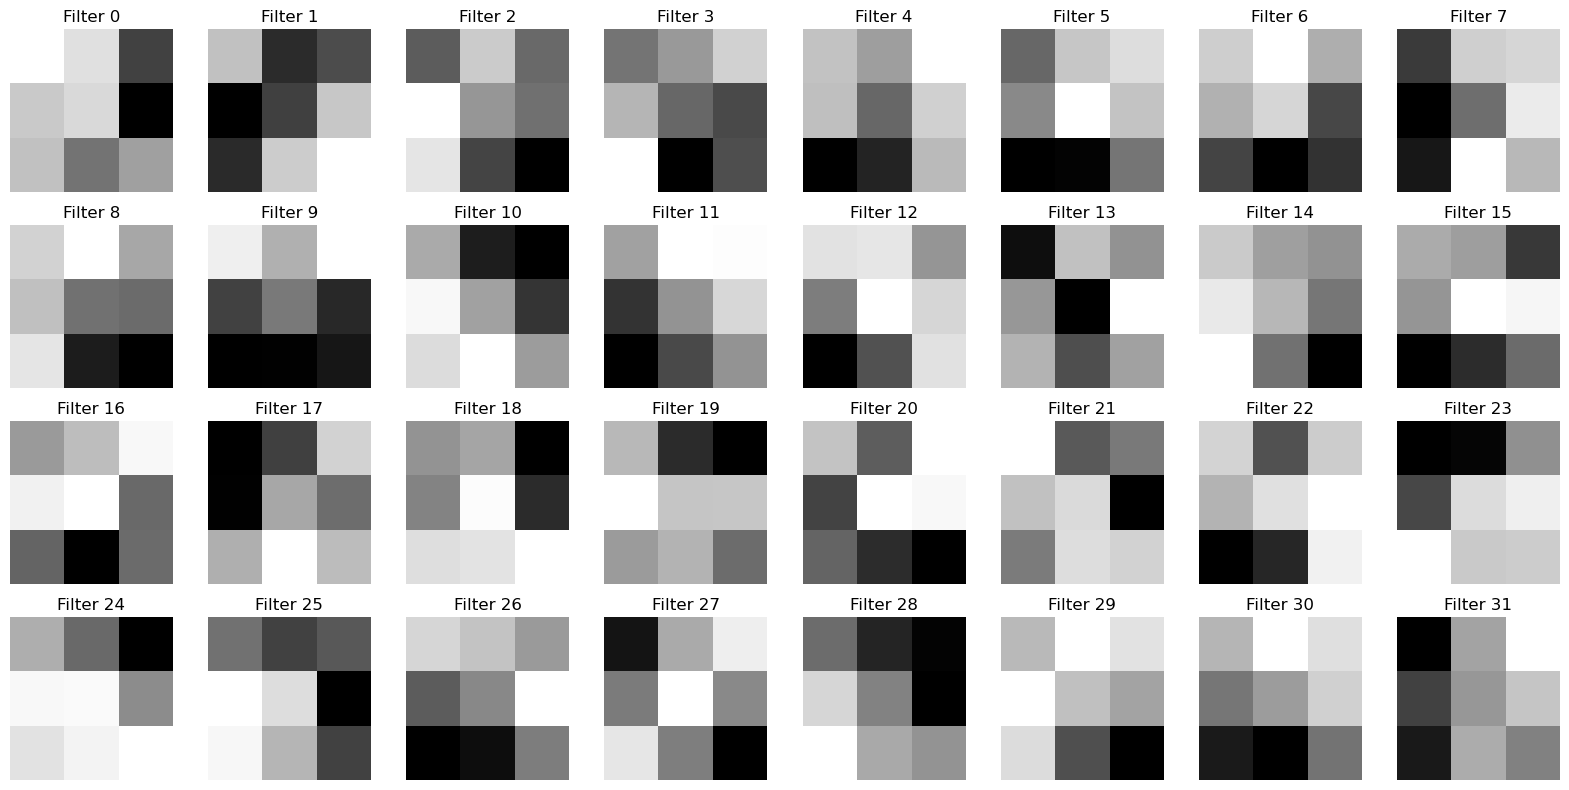

In [36]:
conv_layers = [(i, layer) for i, layer in enumerate(model_CNN.layers) if isinstance(layer, Conv2D)]

if len(conv_layers) == 0:
    raise ValueError("No convolutional layer found in model_CNN.")

conv_layer_index, conv_layer = conv_layers[0]
filters, biases = conv_layer.get_weights()

f_min, f_max = filters.min(), filters.max()
filters_normalized = (filters - f_min) / (f_max - f_min + 1e-12)

print("Convolutional layer index:", conv_layer_index)
print("Filter tensor shape:", filters.shape)

n_filters = filters.shape[-1]
cols = min(8, n_filters)
rows = int(np.ceil(n_filters / cols))

plt.figure(figsize=(2 * cols, 2 * rows))
for i in range(n_filters):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(filters_normalized[:, :, 0, i], cmap="gray")
    plt.title(f"Filter {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Activation maps

Activation maps show the response of intermediate layers to a selected input image. A bright region in an activation map indicates that the corresponding filter is strongly activated in that spatial region. These plots are qualitative: individual maps are not always directly interpretable, but they show how the original image is progressively transformed into learned feature representations.

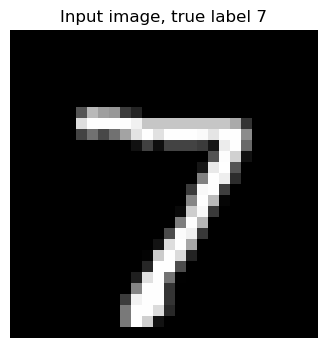

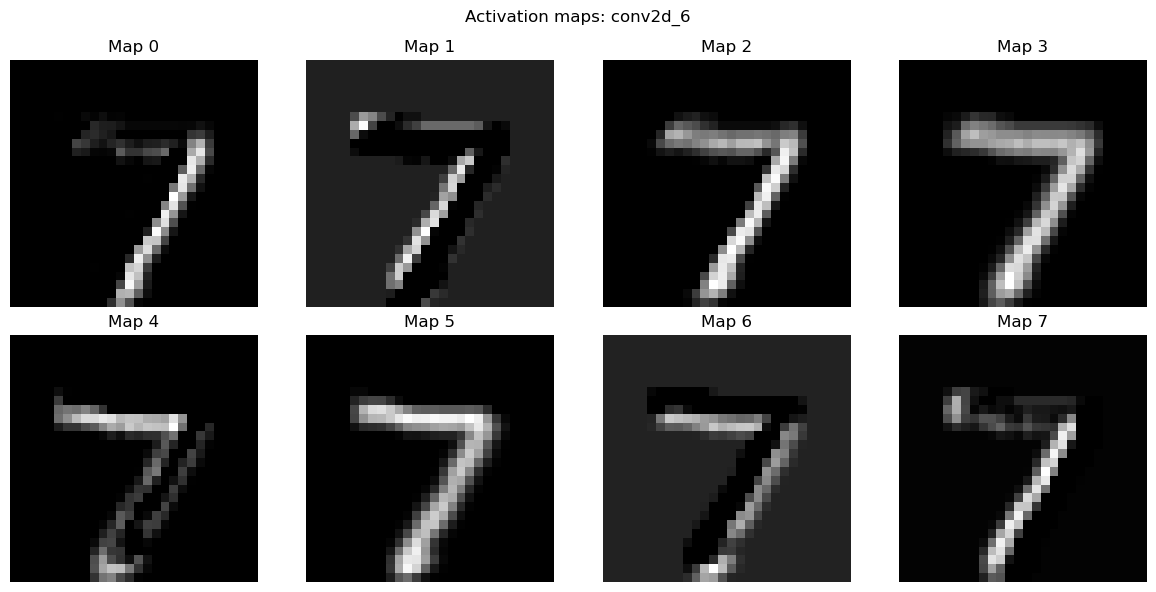

In [37]:
activation_layers = [
    layer for layer in model_CNN.layers
    if isinstance(layer, (Conv2D, MaxPooling2D))
]

activation_model = Model(
    inputs=model_CNN.inputs,
    outputs=[layer.output for layer in activation_layers],
)

test_index = 0
sample_image = X_test_CNN[test_index:test_index + 1]
activations = activation_model.predict(sample_image, verbose=0)

def image_from_cnn_tensor(tensor_image):
    if keras.backend.image_data_format() == "channels_first":
        return tensor_image[0, :, :]
    return tensor_image[:, :, 0]

def display_activation_maps(activations, layer_position, max_maps=8):
    activation = activations[layer_position]

    if keras.backend.image_data_format() == "channels_first":
        maps = activation[0]
    else:
        maps = np.moveaxis(activation[0], -1, 0)

    n_maps = min(max_maps, maps.shape[0])
    cols = min(4, n_maps)
    rows = int(np.ceil(n_maps / cols))

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(n_maps):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(maps[i], cmap="gray")
        plt.title(f"Map {i}")
        plt.axis("off")

    layer_name = activation_layers[layer_position].name
    plt.suptitle(f"Activation maps: {layer_name}")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(image_from_cnn_tensor(X_test_CNN[test_index]), cmap="gray")
plt.title(f"Input image, true label {y_test[test_index]}")
plt.axis("off")
plt.show()

# Layer position 0 corresponds to the first Conv2D layer among activation_layers.
display_activation_maps(activations, layer_position=0, max_maps=8)

### Final observation

The supplementary visualizations confirm the qualitative role of the convolutional part of the network. The first filters are small local detectors, while the activation maps show where these detectors respond on a specific digit image. The classifier is therefore not based on isolated pixels only, but on spatially organized features extracted before the final dense classification layers.